# WiDS Datathon 2020 - Meeting 5: Uncertainty and Confidence in the Model

This notebook addresses **Meeting 5** from `Course project.pdf`:

- Add uncertainty measures to global performance measures using bootstraps.
- Explain the meaning of those uncertainty measures in terms that Dr. Smith can understand.

It uses the saved outputs from the previous notebooks under `notebooks/best_model_info/`, especially the held-out predictions from Meeting 2. The original PDFs and prior notebooks are treated as read-only inputs.

## What the Resampling Lecture Requires Us to Act On

The lecture distinguishes several uncertainty questions. This notebook touches each one explicitly:

| Lecture aspect | Relevant lecture slide | How it is handled here |
|---|---:|---|
| Final performance metrics need uncertainty, not only point estimates | Slide 4, **Uncertainty Estimation for Performance Metrics** | We bootstrap held-out rows to estimate sampling variability in metrics. |
| Resampling approximates what would happen if a new sample were drawn | Slide 5, **Resampling Methods**; Slide 19, **The Bootstrap** | We repeatedly resample patients with replacement and recompute each metric. |
| Hold-out bootstrap validates a given trained model | Slide 29, **Bootstrapping on Hold-Out Set** | We use saved predictions, so the intervals describe uncertainty for this specific trained CatBoost model on future similar ICU patients. |
| Prediction uncertainty is a separate question from model performance uncertainty | Slide 35, **Uncertainty Estimation for Predictions**; Slides 43-45, **How to Estimate Prediction Uncertainty?** | We estimate uncertainty in calibrated risk groups and in decision stability around the 12% escalation cutoff. |
| Calibration connects predicted risks to observed outcome rates | Slides 46-48, **Uncertainty via Calibration / Connection with Calibration** | Before showing calibration uncertainty, we recalibrate CatBoost probabilities on the validation set and evaluate calibrated probabilities on the held-out test set. |

In [64]:
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt

from scipy.stats import norm
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    roc_auc_score,
)

RANDOM_STATE = 42
N_BOOT = 2000
CAPACITY_PCT = 12.0
ALPHA = 0.05

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "notebooks":
    NOTEBOOK_DIR = Path("notebooks")

ARTIFACT_DIR = NOTEBOOK_DIR / "best_model_info"

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

In [65]:
with open(ARTIFACT_DIR / "metadata.json", "r") as f:
    metadata = json.load(f)

eval_pred = pd.read_csv(ARTIFACT_DIR / "eval_predictions.csv")
test_pred = pd.read_csv(ARTIFACT_DIR / "test_predictions.csv")
cv_summary = pd.read_csv(ARTIFACT_DIR / "cv_model_comparison.csv")
model_summary = pd.read_csv(ARTIFACT_DIR / "model_family_comparison_summary.csv")
apache_eval = pd.read_csv(ARTIFACT_DIR / "apache_eval_scores.csv")

print("Best model:", metadata["best_model_name"])
print("Validation rows:", len(eval_pred), "Test rows:", len(test_pred))
print("Validation death rate:", round(eval_pred["y_true"].mean(), 4))
print("Test death rate:", round(test_pred["y_true"].mean(), 4))
print("Validation top-12% threshold:", round(metadata["validation_threshold_top_12pct"], 4))
print("Test top-12% threshold:", round(metadata["test_threshold_top_12pct"], 4))

Best model: CatBoost
Validation rows: 12382 Test rows: 9172
Validation death rate: 0.0863
Test death rate: 0.0863
Validation top-12% threshold: 0.6079
Test top-12% threshold: 0.612


## Probability Calibration Before Calibration Uncertainty

The saved CatBoost scores are useful for ranking, but a score of 0.30 should only be treated as a 30% mortality risk after calibration has been checked or adjusted. Following the lecture's calibration slides (Slides 46-48), we fit an isotonic calibration map on the validation set and apply it to the untouched test set before showing calibration uncertainty.

Clinically: this is like recalibrating a monitor before interpreting small changes. The model may rank patients correctly, but calibration asks whether its probability numbers match observed mortality rates.

In [66]:
calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(eval_pred["predicted_probability"], eval_pred["y_true"])

eval_pred = eval_pred.copy()
test_pred = test_pred.copy()
eval_pred["calibrated_probability"] = calibrator.predict(eval_pred["predicted_probability"])
test_pred["calibrated_probability"] = calibrator.predict(test_pred["predicted_probability"])

calibration_check = pd.DataFrame([
    {
        "split": "validation (calibration fit set)",
        "raw_brier": brier_score_loss(eval_pred["y_true"], eval_pred["predicted_probability"]),
        "calibrated_brier": brier_score_loss(eval_pred["y_true"], eval_pred["calibrated_probability"]),
        "raw_auc": roc_auc_score(eval_pred["y_true"], eval_pred["predicted_probability"]),
        "calibrated_auc": roc_auc_score(eval_pred["y_true"], eval_pred["calibrated_probability"]),
    },
    {
        "split": "test (held out after calibration)",
        "raw_brier": brier_score_loss(test_pred["y_true"], test_pred["predicted_probability"]),
        "calibrated_brier": brier_score_loss(test_pred["y_true"], test_pred["calibrated_probability"]),
        "raw_auc": roc_auc_score(test_pred["y_true"], test_pred["predicted_probability"]),
        "calibrated_auc": roc_auc_score(test_pred["y_true"], test_pred["calibrated_probability"]),
    },
])
calibration_check["brier_change"] = calibration_check["calibrated_brier"] - calibration_check["raw_brier"]
calibration_check["auc_change"] = calibration_check["calibrated_auc"] - calibration_check["raw_auc"]
calibration_check.round(4)

,split,raw_brier,calibrated_brier,raw_auc,calibrated_auc,brier_change,auc_change
0,validation (calibration fit set),0.0962,0.0548,0.8909,0.8932,-0.0415,0.0023
1,test (held out after calibration),0.0944,0.0540,0.8932,0.8923,-0.0403,-0.0009


## Context from Meeting 2

Meeting 2 selected the best model using cross-validation and saved a separate validation and test set. The CV standard deviation below is useful for model selection, but the lecture warns that formal intervals for final reported performance are better estimated by bootstrap on held-out data.

In [67]:
cv_summary.sort_values("roc_auc_mean", ascending=False).round(4)

,model,roc_auc_mean,roc_auc_std
0,CatBoost,0.8805,0.0028
1,LightGBM,0.8730,0.0031
2,Logistic Regression,0.8634,0.0024
3,XGBoost,0.8580,0.0053
4,Random Forest,0.8565,0.0055


In [68]:
model_summary.round(3)

,Model,ROC AUC,PR AUC,Brier,Lift @10%,Threshold,Sensitivity,Specificity,PPV,NPV,% Flagged,F1 @cutoff
0,Logistic Regression,0.865,0.465,0.145,4.983,0.719,0.546,0.920,0.393,0.955,12.001,0.457
1,Random Forest,0.862,0.443,0.062,5.011,0.190,0.546,0.919,0.388,0.955,12.147,0.454
2,XGBoost,0.869,0.484,0.139,5.001,0.666,0.560,0.922,0.403,0.957,12.001,0.469
3,LightGBM,0.879,0.498,0.141,5.273,0.695,0.572,0.923,0.411,0.958,12.001,0.478
4,CatBoost,0.891,0.534,0.096,5.534,0.608,0.606,0.926,0.436,0.961,12.001,0.507
5,APACHE Baseline,0.837,0.401,0.064,4.768,0.140,0.532,0.916,0.374,0.954,12.284,0.439


## Bootstrap Helpers

For each bootstrap replicate, we sample held-out patients with replacement and recompute the metrics. This answers:

> If this trained model were evaluated on another similar ICU sample, how much might the reported metric move just because of patient sampling?

For threshold-based metrics, we keep the policy as **review the highest-risk 12%** in the bootstrap sample, matching the operational policy from Meeting 2. This keeps workload fixed while measuring uncertainty in sensitivity, PPV, and related metrics.

In [69]:
def capacity_flags(scores, capacity_pct=CAPACITY_PCT):
    threshold = np.quantile(scores, 1 - capacity_pct / 100)
    return (scores >= threshold).astype(int), threshold


def threshold_metrics(y_true, scores, capacity_pct=CAPACITY_PCT):
    flags, threshold = capacity_flags(scores, capacity_pct)
    tn, fp, fn, tp = confusion_matrix(y_true, flags, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    ppv = tp / (tp + fp) if (tp + fp) else np.nan
    npv = tn / (tn + fn) if (tn + fn) else np.nan
    f1 = 2 * ppv * sensitivity / (ppv + sensitivity) if (ppv + sensitivity) else np.nan
    return {
        "threshold": threshold,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "ppv": ppv,
        "npv": npv,
        "f1": f1,
        "flagged_pct": 100 * flags.mean(),
    }


def all_metrics(y_true, scores, capacity_pct=CAPACITY_PCT):
    out = {
        "roc_auc": roc_auc_score(y_true, scores),
        "pr_auc": average_precision_score(y_true, scores),
        "brier": brier_score_loss(y_true, scores),
    }
    out.update(threshold_metrics(y_true, scores, capacity_pct))
    return out


def bootstrap_metrics(y_true, scores, n_boot=N_BOOT, capacity_pct=CAPACITY_PCT, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    n = len(y_true)
    rows = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        y_b = y_true[idx]
        if y_b.min() == y_b.max():
            continue
        rows.append(all_metrics(y_b, scores[idx], capacity_pct))
    return pd.DataFrame(rows)


def summarize_bootstrap(point, boot, metrics=None, alpha=ALPHA):
    if metrics is None:
        metrics = [c for c in point.index if c in boot.columns]
    rows = []
    for m in metrics:
        vals = boot[m].dropna()
        rows.append({
            "metric": m,
            "point_estimate": point[m],
            "bootstrap_mean": vals.mean(),
            "standard_error": vals.std(ddof=1),
            "ci_low": vals.quantile(alpha / 2),
            "ci_high": vals.quantile(1 - alpha / 2),
        })
    return pd.DataFrame(rows)

## Global Performance Uncertainty for the CatBoost Model

These are the uncertainty intervals Dr. Smith asked for. Read each 95% interval as a plausible range for the model's metric on future ICU patients drawn from the same type of population.

In [70]:
metric_order = [
    "roc_auc", "pr_auc", "brier", "sensitivity", "specificity", "ppv", "npv", "f1", "flagged_pct", "threshold"
]

results = {}
for split_name, df in {"validation": eval_pred, "test": test_pred}.items():
    y = df["y_true"].to_numpy()
    p = df["predicted_probability"].to_numpy()
    point = pd.Series(all_metrics(y, p))
    boot = bootstrap_metrics(y, p, seed=RANDOM_STATE + (0 if split_name == "validation" else 100))
    summary = summarize_bootstrap(point, boot, metric_order)
    results[split_name] = {"point": point, "boot": boot, "summary": summary}
    print(f"{split_name}: {len(boot)} bootstrap replicates")

results["test"]["summary"].round(4)

validation: 2000 bootstrap replicates
test: 2000 bootstrap replicates


,metric,point_estimate,bootstrap_mean,standard_error,ci_low,ci_high
0,roc_auc,0.8932,0.8931,0.0058,0.8816,0.9043
1,pr_auc,0.5616,0.5613,0.0174,0.5256,0.5955
2,brier,0.0944,0.0944,0.0019,0.0908,0.0982
3,sensitivity,0.6086,0.6076,0.0162,0.5763,0.6401
4,specificity,0.9261,0.9260,0.0020,0.9221,0.9298
5,ppv,0.4378,0.4369,0.0162,0.4051,0.4687
6,npv,0.9616,0.9615,0.0023,0.9569,0.9659
7,f1,0.5092,0.5082,0.0145,0.4795,0.5356
8,flagged_pct,12.0039,12.0093,0.0081,12.0039,12.0257
9,threshold,0.6120,0.6121,0.0091,0.5949,0.6292


In [71]:
combined_summary = pd.concat(
    [s["summary"].assign(split=name) for name, s in results.items()],
    ignore_index=True,
)
combined_summary = combined_summary[["split", "metric", "point_estimate", "standard_error", "ci_low", "ci_high"]]
combined_summary.round(4)

,split,metric,point_estimate,standard_error,ci_low,ci_high
0,validation,roc_auc,0.8909,0.0048,0.8816,0.9003
1,validation,pr_auc,0.5344,0.0156,0.5047,0.5669
2,validation,brier,0.0962,0.0016,0.0931,0.0994
3,validation,sensitivity,0.6062,0.0134,0.5791,0.6315
4,validation,specificity,0.9259,0.0017,0.9227,0.9291
5,validation,ppv,0.4361,0.0140,0.4092,0.4624
6,validation,npv,0.9614,0.0019,0.9575,0.9651
7,validation,f1,0.5072,0.0123,0.4834,0.5304
8,validation,flagged_pct,12.0013,0.0061,12.0013,12.0174
9,validation,threshold,0.6079,0.0067,0.5927,0.6202


### What the uncertainty columns mean for Dr. Smith

| Shown measure | Lecture reference | Meaning in clinical language |
|---|---:|---|
| `standard_error` | Slide 4 and Slide 19 | The typical amount this metric would wiggle if we evaluated the same trained model on another similar ICU sample. Smaller is more stable. |
| `ci_low` to `ci_high` | Slide 29 | A 95% bootstrap interval: a plausible range for the metric in a future similar ICU cohort. It is not a promise for one patient; it is uncertainty about the reported model performance. |
| ROC-AUC interval | Slide 4 | Uncertainty in ranking: how reliably the model gives higher risk to patients who die than to patients who survive. |
| PR-AUC interval | Slide 4 | Uncertainty in performance for the rare outcome setting, where hospital death is uncommon and precision matters. |
| Brier interval | Slides 46-48 | Uncertainty in probability accuracy: whether predicted risks are numerically close to observed outcomes. Lower is better. |
| Sensitivity interval | Slide 29 | Uncertainty in how many eventual deaths the top-12% escalation list catches. This is the coverage of high-risk patients. |
| Specificity interval | Slide 29 | Uncertainty in how many survivors are correctly left off the escalation list. |
| PPV interval | Slide 29 | Uncertainty in clinical yield: among escalated patients, how many die in hospital. |
| NPV interval | Slide 29 | Uncertainty in reassurance: among non-escalated patients, how many survive. |
| F1 interval | Slide 29 | A single-number summary of the balance between catching deaths and keeping escalation yield high. |
| Threshold / flagged-percent interval | Slide 29 | Uncertainty in the operational cutoff needed to keep the workload around the chosen top 12%. |

/tmp/ipykernel_3373270/1530849693.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([val, tst], labels=["validation", "test"], patch_artist=True)
/tmp/ipykernel_3373270/1530849693.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([val, tst], labels=["validation", "test"], patch_artist=True)
/tmp/ipykernel_3373270/1530849693.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([val, tst], labels=["validation", "test"], patch_artist=True)
/tmp/ipykernel_3373270/1530849693.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matpl

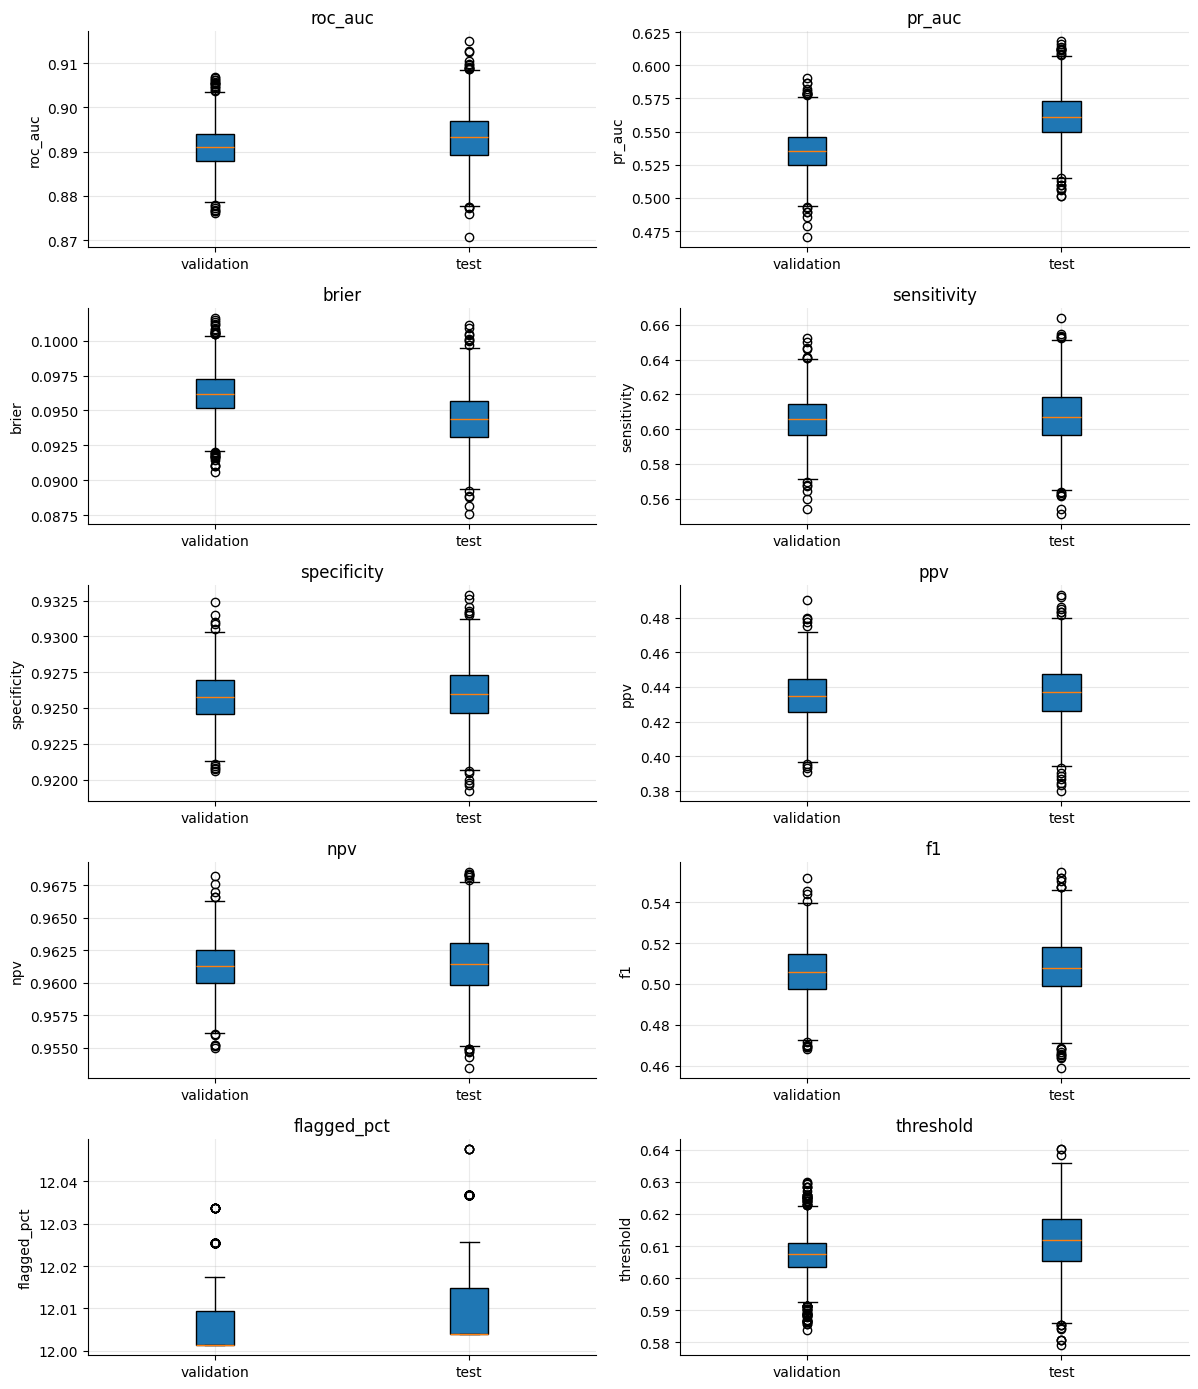

In [72]:
# Box plots of bootstrap distributions (validation vs test) for each metric
metrics = metric_order  # ['roc_auc', 'pr_auc', 'brier', 'sensitivity', ...]
fig, axes = plt.subplots(5, 2, figsize=(12, 14))
axes = axes.ravel()

for ax, m in zip(axes, metrics):
    val = results["validation"]["boot"][m].dropna().to_numpy()
    tst = results["test"]["boot"][m].dropna().to_numpy()
    ax.boxplot([val, tst], labels=["validation", "test"], patch_artist=True)
    ax.set_title(m)
    ax.set_ylabel(m)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

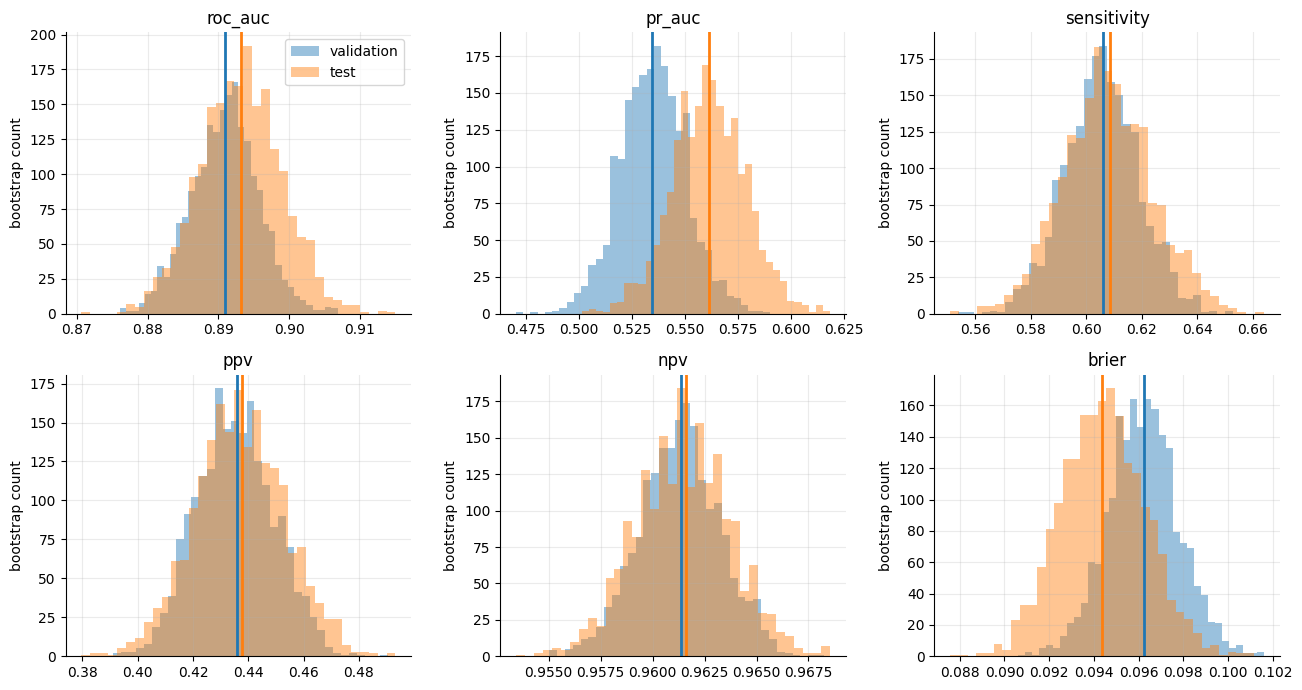

In [73]:
plot_metrics = ["roc_auc", "pr_auc", "sensitivity", "ppv", "npv", "brier"]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.ravel()

for ax, metric in zip(axes, plot_metrics):
    for split_name, color in [("validation", "tab:blue"), ("test", "tab:orange")]:
        vals = results[split_name]["boot"][metric]
        ax.hist(vals, bins=35, alpha=0.45, color=color, label=split_name)
        ax.axvline(results[split_name]["point"][metric], color=color, linewidth=2)
    ax.set_title(metric)
    ax.set_ylabel("bootstrap count")

axes[0].legend()
plt.tight_layout()
plt.show()

### Plain-language readout for Dr. Smith

The test-set point estimate is not a single truth. It is the result from one held-out sample of 9,172 ICU admissions. The bootstrap interval says how much that number would plausibly move if we saw another similar group of ICU patients.

For example, ROC-AUC describes ranking ability: among a randomly chosen patient who died and a randomly chosen survivor, how often did the model give the patient who died a higher risk score? PPV at the 12% cutoff describes workload yield: among patients sent for escalation review, how many died in hospital. Sensitivity describes coverage: among patients who died, how many were caught by the escalation list.

## Statistical Comparison Against APACHE on Validation

The previous notebooks compared CatBoost to APACHE. Here we add two uncertainty views:

1. **DeLong's paired test** for the ROC-AUC difference, which is the standard statistical test for comparing two correlated AUCs measured on the same patients. We show both raw CatBoost vs APACHE and calibrated CatBoost vs APACHE.
2. **Paired bootstrap intervals** for ROC-AUC, PR-AUC, and Brier score differences, so the non-AUC measures also get uncertainty ranges.

In [74]:
def compute_midrank(x):
    x = np.asarray(x)
    order = np.argsort(x)
    sorted_x = x[order]
    midranks = np.zeros(len(x), dtype=float)
    i = 0
    while i < len(x):
        j = i
        while j < len(x) and sorted_x[j] == sorted_x[i]:
            j += 1
        midranks[order[i:j]] = 0.5 * (i + j - 1) + 1
        i = j
    return midranks


def fast_delong(predictions_sorted_transposed, n_positive):
    m = n_positive
    n = predictions_sorted_transposed.shape[1] - m
    positives = predictions_sorted_transposed[:, :m]
    negatives = predictions_sorted_transposed[:, m:]
    k = predictions_sorted_transposed.shape[0]

    tx = np.empty((k, m))
    ty = np.empty((k, n))
    tz = np.empty((k, m + n))
    for r in range(k):
        tx[r] = compute_midrank(positives[r])
        ty[r] = compute_midrank(negatives[r])
        tz[r] = compute_midrank(predictions_sorted_transposed[r])

    aucs = tz[:, :m].sum(axis=1) / (m * n) - (m + 1) / (2 * n)
    v01 = (tz[:, :m] - tx) / n
    v10 = 1 - (tz[:, m:] - ty) / m
    covariance = np.cov(v01) / m + np.cov(v10) / n
    return aucs, np.atleast_2d(covariance)


def delong_roc_test(y_true, score_a, score_b, name_a="model_a", name_b="model_b"):
    y_true = np.asarray(y_true).astype(int)
    scores = np.vstack([score_a, score_b])
    order = np.argsort(-y_true)
    n_positive = int(y_true.sum())
    aucs, covariance = fast_delong(scores[:, order], n_positive)
    delta = aucs[0] - aucs[1]
    variance = covariance[0, 0] + covariance[1, 1] - 2 * covariance[0, 1]
    se = np.sqrt(max(variance, 0))
    z = delta / se if se > 0 else np.nan
    p_value = 2 * norm.sf(abs(z)) if np.isfinite(z) else np.nan
    ci_low = delta - norm.ppf(1 - ALPHA / 2) * se
    ci_high = delta + norm.ppf(1 - ALPHA / 2) * se
    return pd.DataFrame([{
        "comparison": f"{name_a} - {name_b}",
        f"{name_a}_roc_auc": aucs[0],
        f"{name_b}_roc_auc": aucs[1],
        "delta_roc_auc": delta,
        "standard_error": se,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "z": z,
        "p_value": p_value,
    }])

### Did calibration hurt ROC-AUC?

Calibration can change AUC when the calibration method is not strictly ranking-preserving. Isotonic calibration can map several nearby raw scores to the same calibrated value, so it may slightly reduce discrimination even while improving probability accuracy.

We test this directly with DeLong's paired ROC-AUC test, comparing raw CatBoost scores against calibrated CatBoost scores on the same patients. The test-set row is the most important one because the validation set was used to fit the calibrator.

In [75]:
calibration_auc_delong = pd.concat([
    delong_roc_test(
        eval_pred["y_true"],
        eval_pred["calibrated_probability"],
        eval_pred["predicted_probability"],
        name_a="calibrated_catboost",
        name_b="raw_catboost",
    ).assign(split="validation (calibration fit set)"),
    delong_roc_test(
        test_pred["y_true"],
        test_pred["calibrated_probability"],
        test_pred["predicted_probability"],
        name_a="calibrated_catboost",
        name_b="raw_catboost",
    ).assign(split="test (held out after calibration)"),
], ignore_index=True)

calibration_auc_delong = calibration_auc_delong[[
    "split",
    "calibrated_catboost_roc_auc",
    "raw_catboost_roc_auc",
    "delta_roc_auc",
    "standard_error",
    "ci_low",
    "ci_high",
    "p_value",
]]
calibration_auc_delong.round(4)

,split,calibrated_catboost_roc_auc,raw_catboost_roc_auc,delta_roc_auc,standard_error,ci_low,ci_high,p_value
0,validation (calibration fit set),0.8932,0.8909,0.0023,0.0003,0.0016,0.0030,0.0000
1,test (held out after calibration),0.8923,0.8932,-0.0009,0.0004,-0.0016,-0.0001,0.0268


Interpretation: `delta_roc_auc` is calibrated CatBoost minus raw CatBoost. A negative value means calibration lowered AUC. If the DeLong confidence interval includes zero, the AUC change is not statistically clear. If it is below zero and the p-value is small, calibration likely hurt ranking performance, even if it helped probability calibration or Brier score.

In [76]:
cat_eval = eval_pred[["y_true", "predicted_probability", "calibrated_probability"]].rename(
    columns={
        "predicted_probability": "catboost",
        "calibrated_probability": "calibrated_catboost",
    }
)
apache_eval_aligned = apache_eval.rename(columns={"apache_icu_death_prob": "apache"})
comparison_df = pd.concat([cat_eval, apache_eval_aligned[["apache"]]], axis=1).dropna()

comparison_df.head()

,y_true,catboost,calibrated_catboost,apache
0,0,0.078468,0.013986,0.11
1,0,0.133147,0.026408,0.04
2,0,0.375750,0.083106,0.08
3,0,0.155900,0.032070,0.03
4,0,0.024762,0.001548,0.01


In [77]:
apache_delong_summary = pd.concat([
    delong_roc_test(
        comparison_df["y_true"],
        comparison_df["catboost"],
        comparison_df["apache"],
        name_a="raw_catboost",
        name_b="apache",
    ).assign(comparison_type="raw CatBoost vs APACHE"),
    delong_roc_test(
        comparison_df["y_true"],
        comparison_df["calibrated_catboost"],
        comparison_df["apache"],
        name_a="calibrated_catboost",
        name_b="apache",
    ).assign(comparison_type="calibrated CatBoost vs APACHE"),
], ignore_index=True)

apache_delong_summary.round(4)

,comparison,raw_catboost_roc_auc,apache_roc_auc,delta_roc_auc,standard_error,ci_low,ci_high,z,p_value,comparison_type,calibrated_catboost_roc_auc
0,raw_catboost - apache,0.8909,0.8371,0.0538,0.0061,0.0418,0.0657,8.8178,0.0,raw CatBoost vs APACHE,NaN
1,calibrated_catboost - apache,NaN,0.8371,0.0561,0.0061,0.0442,0.0680,9.2496,0.0,calibrated CatBoost vs APACHE,0.8932


### Interpreting DeLong's test for doctors

DeLong's test asks a narrow but important question: when CatBoost and APACHE are scored on the same validation patients, is the ROC-AUC gap larger than we would expect from sampling noise alone? This connects to the lecture's performance-metric uncertainty framing (Slide 4), but uses an analytic paired AUC test rather than a bootstrap.

The first row compares raw CatBoost probabilities with APACHE. The second row compares calibrated CatBoost probabilities with APACHE, which is the direct answer after calibration. A small `p_value` supports the statement that CatBoost ranks fatal vs. surviving cases better than APACHE on this validation cohort. The `ci_low` to `ci_high` range is the plausible AUC advantage; if it stays above zero, the ranking improvement is clinically more credible than a one-split accident.

In [78]:
def paired_bootstrap_differences(df, n_boot=N_BOOT, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    n = len(df)
    rows = []
    arr = df[["y_true", "catboost", "apache"]].to_numpy()
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        sample = arr[idx]
        y = sample[:, 0].astype(int)
        if y.min() == y.max():
            continue
        cat = sample[:, 1]
        apache = sample[:, 2]
        rows.append({
            "catboost_roc_auc": roc_auc_score(y, cat),
            "apache_roc_auc": roc_auc_score(y, apache),
            "delta_roc_auc": roc_auc_score(y, cat) - roc_auc_score(y, apache),
            "catboost_pr_auc": average_precision_score(y, cat),
            "apache_pr_auc": average_precision_score(y, apache),
            "delta_pr_auc": average_precision_score(y, cat) - average_precision_score(y, apache),
            "catboost_brier": brier_score_loss(y, cat),
            "apache_brier": brier_score_loss(y, apache),
            "delta_brier": brier_score_loss(y, cat) - brier_score_loss(y, apache),
        })
    return pd.DataFrame(rows)

paired_boot = paired_bootstrap_differences(comparison_df)
paired_point = pd.Series({
    "catboost_roc_auc": roc_auc_score(comparison_df["y_true"], comparison_df["catboost"]),
    "apache_roc_auc": roc_auc_score(comparison_df["y_true"], comparison_df["apache"]),
    "delta_roc_auc": roc_auc_score(comparison_df["y_true"], comparison_df["catboost"]) - roc_auc_score(comparison_df["y_true"], comparison_df["apache"]),
    "catboost_pr_auc": average_precision_score(comparison_df["y_true"], comparison_df["catboost"]),
    "apache_pr_auc": average_precision_score(comparison_df["y_true"], comparison_df["apache"]),
    "delta_pr_auc": average_precision_score(comparison_df["y_true"], comparison_df["catboost"]) - average_precision_score(comparison_df["y_true"], comparison_df["apache"]),
    "catboost_brier": brier_score_loss(comparison_df["y_true"], comparison_df["catboost"]),
    "apache_brier": brier_score_loss(comparison_df["y_true"], comparison_df["apache"]),
    "delta_brier": brier_score_loss(comparison_df["y_true"], comparison_df["catboost"]) - brier_score_loss(comparison_df["y_true"], comparison_df["apache"]),
})

paired_summary = summarize_bootstrap(
    paired_point,
    paired_boot,
    ["catboost_roc_auc", "apache_roc_auc", "delta_roc_auc", "catboost_pr_auc", "apache_pr_auc", "delta_pr_auc", "catboost_brier", "apache_brier", "delta_brier"],
)
paired_summary.round(4)

,metric,point_estimate,bootstrap_mean,standard_error,ci_low,ci_high
0,catboost_roc_auc,0.8909,0.8910,0.0048,0.8816,0.9003
1,apache_roc_auc,0.8371,0.8373,0.0064,0.8242,0.8494
2,delta_roc_auc,0.0538,0.0536,0.0061,0.0420,0.0657
3,catboost_pr_auc,0.5344,0.5352,0.0156,0.5047,0.5669
4,apache_pr_auc,0.4011,0.4021,0.0163,0.3700,0.4333
5,delta_pr_auc,0.1332,0.1331,0.0155,0.1016,0.1628
6,catboost_brier,0.0962,0.0962,0.0016,0.0931,0.0994
7,apache_brier,0.0638,0.0638,0.0018,0.0603,0.0673
8,delta_brier,0.0324,0.0324,0.0020,0.0287,0.0362


### Interpreting paired bootstrap differences

The paired bootstrap resamples patients, keeping each patient's CatBoost and APACHE scores together. This follows the hold-out bootstrap idea in Slide 29: the uncertainty is about how the comparison might change in another similar validation sample.

For `delta_roc_auc` and `delta_pr_auc`, positive values favor CatBoost. For `delta_brier`, negative values favor CatBoost because lower Brier score means better probability accuracy. Doctors can read each interval as: “how large is the likely practical advantage, not just who won the point estimate?”

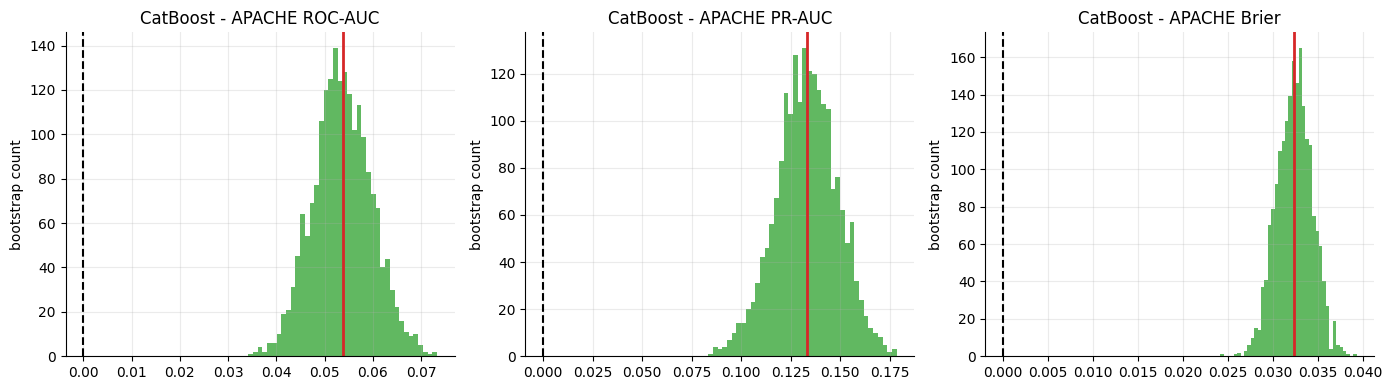

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric, title in zip(
    axes,
    ["delta_roc_auc", "delta_pr_auc", "delta_brier"],
    ["CatBoost - APACHE ROC-AUC", "CatBoost - APACHE PR-AUC", "CatBoost - APACHE Brier"],
):
    vals = paired_boot[metric]
    ax.hist(vals, bins=40, color="tab:green", alpha=0.75)
    ax.axvline(0, color="black", linestyle="--")
    ax.axvline(paired_point[metric], color="tab:red", linewidth=2)
    ax.set_title(title)
    ax.set_ylabel("bootstrap count")
plt.tight_layout()
plt.show()

Interpretation: if the bootstrap interval for `delta_roc_auc` and `delta_pr_auc` stays above zero, the model's ranking advantage over APACHE is not just a lucky validation split. For Brier score, lower is better, so a negative `delta_brier` favors CatBoost. DeLong's test is the formal paired test for the ROC-AUC part of this claim.

## Calibration and Prediction-Level Uncertainty

Now that the CatBoost probabilities have been calibrated, we can show uncertainty in calibrated risk groups. This section follows the prediction-uncertainty and calibration parts of the lecture (Slides 35 and 46-48).

A predicted probability should not be read as exact individual truth. The clinically safer interpretation is:

> Among patients with similar calibrated scores, what fraction died, and how uncertain is that fraction?

The table and plot below group test-set patients by calibrated predicted-risk deciles and bootstrap the observed mortality rate in each group.

In [80]:
def calibration_bins_with_bootstrap(df, score_col="calibrated_probability", n_bins=10, n_boot=N_BOOT, seed=RANDOM_STATE):
    work = df[["y_true", score_col]].copy().rename(columns={score_col: "score"})
    work["bin"] = pd.qcut(work["score"], q=n_bins, labels=False, duplicates="drop")
    rng = np.random.default_rng(seed)
    rows = []
    for b, g in work.groupby("bin"):
        y = g["y_true"].to_numpy()
        p = g["score"].to_numpy()
        boot_rates = []
        for _ in range(n_boot):
            idx = rng.integers(0, len(g), size=len(g))
            boot_rates.append(y[idx].mean())
        rows.append({
            "bin": int(b) + 1,
            "n": len(g),
            "predicted_mean": p.mean(),
            "observed_rate": y.mean(),
            "obs_ci_low": np.quantile(boot_rates, ALPHA / 2),
            "obs_ci_high": np.quantile(boot_rates, 1 - ALPHA / 2),
            "score_min": p.min(),
            "score_max": p.max(),
        })
    return pd.DataFrame(rows)

cal_test = calibration_bins_with_bootstrap(test_pred, score_col="calibrated_probability", seed=RANDOM_STATE + 200)
cal_test.round(4)

,bin,n,predicted_mean,observed_rate,obs_ci_low,obs_ci_high,score_min,score_max
0,1,2170,0.0010,0.0032,0.0009,0.0060,0.0000,0.0015
1,2,869,0.0051,0.0069,0.0023,0.0127,0.0036,0.0055
2,3,1017,0.0135,0.0118,0.0059,0.0197,0.0088,0.0140
3,4,653,0.0234,0.0199,0.0092,0.0322,0.0148,0.0264
4,5,1333,0.0388,0.0383,0.0278,0.0495,0.0321,0.0434
5,6,451,0.0656,0.0665,0.0443,0.0887,0.0455,0.0673
6,7,1036,0.0982,0.0946,0.0772,0.1129,0.0831,0.1173
7,8,732,0.1753,0.1749,0.1489,0.2036,0.1243,0.2169
8,9,911,0.4913,0.4907,0.4566,0.5236,0.2766,1.0000


### Interpreting calibration uncertainty for doctors

The vertical interval around each decile is a bootstrap confidence interval for the observed death rate in patients with similar calibrated model risk. This is the lecture's calibration idea (Slides 46-48) turned into a clinical statement: if the calibrated score group averages 20%, the interval tells us how certain we are that similar patients truly die at about that rate.

Wide intervals usually mean fewer patients or more outcome variability in that risk band. They should make us cautious about over-interpreting small differences between nearby risk groups.

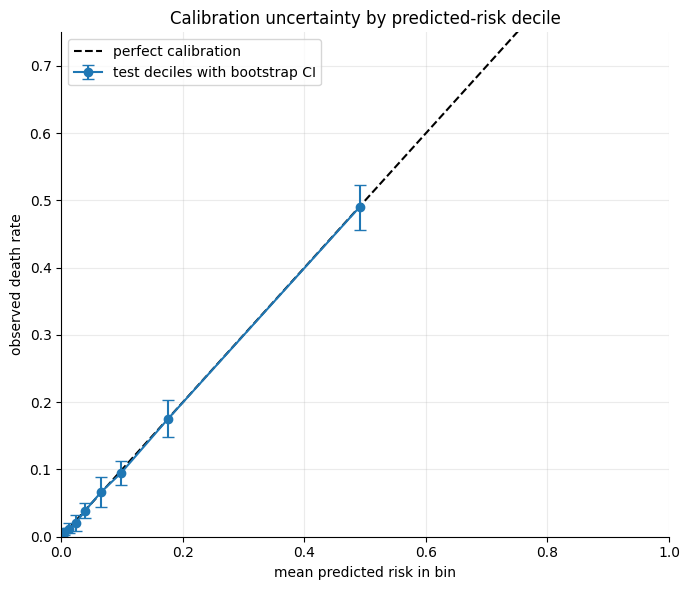

In [81]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], color="black", linestyle="--", label="perfect calibration")
ax.errorbar(
    cal_test["predicted_mean"],
    cal_test["observed_rate"],
    yerr=[cal_test["observed_rate"] - cal_test["obs_ci_low"], cal_test["obs_ci_high"] - cal_test["observed_rate"]],
    fmt="o-",
    capsize=4,
    color="tab:blue",
    label="test deciles with bootstrap CI",
)
ax.set_xlabel("mean predicted risk in bin")
ax.set_ylabel("observed death rate")
ax.set_title("Calibration uncertainty by predicted-risk decile")
ax.set_xlim(0, 1)
ax.set_ylim(0, max(0.75, cal_test["obs_ci_high"].max() + 0.05))
ax.legend()
plt.tight_layout()
plt.show()

## Decision Stability Around the 12% Capacity Cutoff

The model is most useful operationally when we know whether a patient is clearly above or below the escalation threshold. Patients near the cutoff are inherently less stable: a slightly different future sample could move the top-12% threshold enough to change their flag.

This section bootstraps the threshold itself, then asks for each patient: in what fraction of bootstrap thresholds would this saved score be flagged?

In [82]:
def bootstrap_thresholds(scores, n_boot=N_BOOT, capacity_pct=CAPACITY_PCT, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    scores = np.asarray(scores)
    n = len(scores)
    thresholds = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        thresholds[i] = np.quantile(scores[idx], 1 - capacity_pct / 100)
    return thresholds


def decision_stability(df, thresholds, score_col="calibrated_probability"):
    scores = df[score_col].to_numpy()
    stability = (scores[:, None] >= thresholds[None, :]).mean(axis=1)
    out = df.copy()
    out["flag_probability_from_threshold_bootstrap"] = stability
    out["decision_band"] = pd.cut(
        stability,
        bins=[-0.01, 0.05, 0.95, 1.01],
        labels=["stable below cutoff", "near cutoff / unstable", "stable above cutoff"],
    )
    return out

test_threshold_boot = bootstrap_thresholds(test_pred["calibrated_probability"], seed=RANDOM_STATE + 300)
stability_test = decision_stability(test_pred, test_threshold_boot, score_col="calibrated_probability")

threshold_ci = np.quantile(test_threshold_boot, [0.025, 0.5, 0.975])
print("Bootstrap threshold CI for top-12% test policy:", np.round(threshold_ci, 4))

stability_summary = (
    stability_test.groupby("decision_band", observed=True)
    .agg(
        patients=("y_true", "size"),
        mean_calibrated_risk=("calibrated_probability", "mean"),
        observed_death_rate=("y_true", "mean"),
        mean_flag_probability=("flag_probability_from_threshold_bootstrap", "mean"),
    )
    .reset_index()
)
stability_summary.round(4)

Bootstrap threshold CI for top-12% test policy: [0.1731 0.2169 0.2169]


,decision_band,patients,mean_calibrated_risk,observed_death_rate,mean_flag_probability
0,stable below cutoff,7845,0.0339,0.0340,0.000
1,near cutoff / unstable,206,0.1731,0.1942,0.245
2,stable above cutoff,1121,0.4399,0.4326,1.000


### Interpreting threshold uncertainty for doctors

The threshold interval is uncertainty in the operational rule, not uncertainty in disease biology. Under the top-12% capacity policy, the exact calibrated-risk cutoff can move if the ICU sees a slightly different patient mix. This is the hold-out bootstrap idea from Slide 29 applied to the escalation threshold.

`flag_probability_from_threshold_bootstrap` is a decision-stability measure: a value near 1 means the patient is almost always above the top-12% cutoff; near 0 means almost always below; middle values mark borderline cases where a hard yes/no label should be treated cautiously.

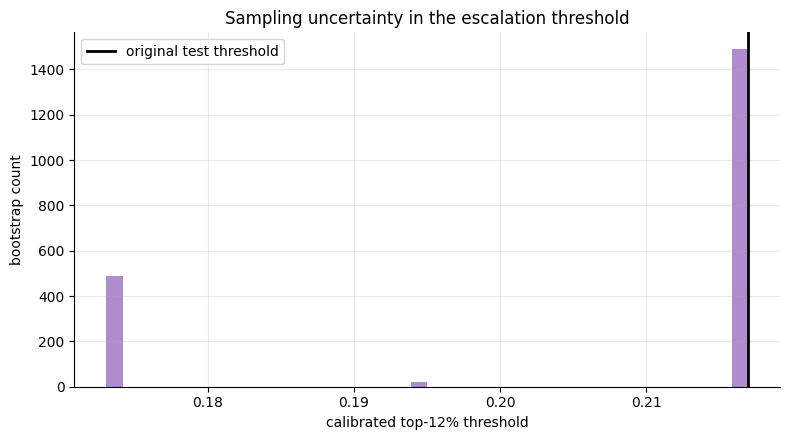

In [83]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(test_threshold_boot, bins=40, color="tab:purple", alpha=0.75)
ax.axvline(np.quantile(test_pred["calibrated_probability"], 1 - CAPACITY_PCT / 100), color="black", linewidth=2, label="original test threshold")
ax.set_xlabel("calibrated top-12% threshold")
ax.set_ylabel("bootstrap count")
ax.set_title("Sampling uncertainty in the escalation threshold")
ax.legend()
plt.tight_layout()
plt.show()

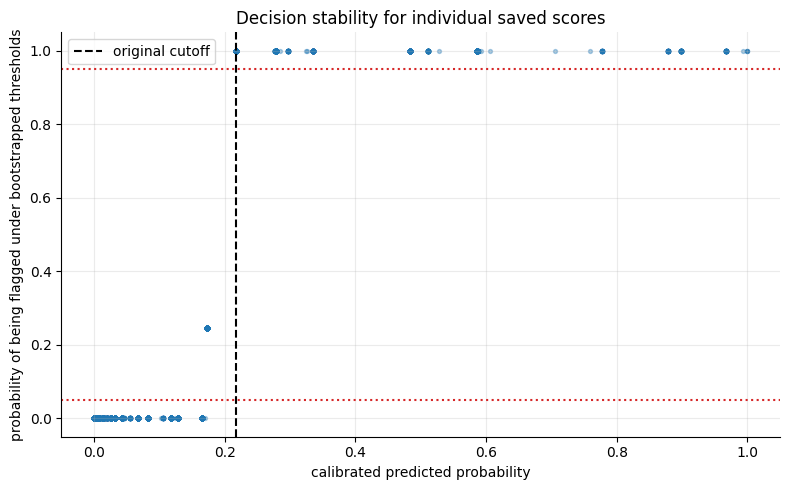

In [84]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    stability_test["calibrated_probability"],
    stability_test["flag_probability_from_threshold_bootstrap"],
    s=8,
    alpha=0.35,
    color="tab:blue",
)
ax.axvline(np.quantile(test_pred["calibrated_probability"], 1 - CAPACITY_PCT / 100), color="black", linestyle="--", label="original cutoff")
ax.axhline(0.05, color="tab:red", linestyle=":")
ax.axhline(0.95, color="tab:red", linestyle=":")
ax.set_xlabel("calibrated predicted probability")
ax.set_ylabel("probability of being flagged under bootstrapped thresholds")
ax.set_title("Decision stability for individual saved scores")
ax.legend()
plt.tight_layout()
plt.show()

Interpretation for Dr. Smith: a patient far above the calibrated cutoff is consistently escalated, and a patient far below is consistently not escalated. The gray zone is around the cutoff; those patients should be treated as borderline rather than as if the model made a perfectly sharp distinction.

## Clinical Report

**What we can say with confidence**

The CatBoost model has strong ranking performance on held-out data. The bootstrap interval around ROC-AUC tells us the ranking result is not a fragile artifact of one test split. Against APACHE, DeLong's paired ROC-AUC test gives the formal statistical comparison for discrimination for both raw and calibrated CatBoost scores, while paired bootstrap intervals show the uncertainty in ROC-AUC, PR-AUC, and Brier differences.

**What the top-12% escalation rule means**

At the chosen capacity, the model escalates roughly one in eight ICU patients. The bootstrap intervals around sensitivity and PPV communicate the tradeoff: sensitivity is the fraction of deaths we expect to catch, while PPV is the fraction of escalated patients who die in hospital. These are operational uncertainty ranges, not just abstract statistics.

**What calibration changes**

Before showing calibration uncertainty, we recalibrated the CatBoost probabilities using the validation set and applied that calibration to the test set. We also tested whether calibration hurt ROC-AUC using DeLong's paired test on raw vs calibrated CatBoost scores. This makes the risk decile plot more clinically meaningful while still checking that probability calibration did not materially damage patient ranking.

**What we should not overclaim**

The intervals in this notebook validate the saved trained model on held-out samples. They do not fully represent what would happen if we reran the entire training, feature selection, tuning, and model selection process from scratch. That would require bootstrapping or otherwise resampling the full development pipeline, which is computationally heavier and requires the original modeling dependencies.

**Prediction-level caution**

A single patient's predicted risk should be described as an estimate, especially near the 12% cutoff. The calibration bins show how calibrated predicted probabilities translate into observed mortality rates for groups of similar-risk patients, and the decision-stability analysis identifies patients whose escalation status is borderline.

## Questions for Review

Is anything unclear about which uncertainty target you want emphasized in the final write-up: uncertainty in **global performance metrics**, uncertainty in **the top-12% escalation decision**, or uncertainty in **individual patient risk estimates**?